<a href="https://colab.research.google.com/github/aaronab810/Dubai-Real-Estate-NLP/blob/main/notebooks/DLD_Market_Indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DLD Market Indicator Construction**

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ==========================
# Project Paths
# ==========================

PROJECT_ROOT = Path("/content/drive/MyDrive/Dubai_Real_Estate_Data/dld")

DATA_DIR = PROJECT_ROOT
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [2]:
df=pd.read_csv(DATA_DIR/'transactions-2026-06-19.csv',low_memory=False)
display(df.head())
display(df.info())
print(df.isna().sum().sort_values(ascending=False))
print('Duplicate rows:',df.duplicated().sum())

,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,...,ACTUAL_AREA,ROOMS_EN,PARKING,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,MASTER_PROJECT_EN,PROJECT_EN
0,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,284.65,4 B/R,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK
1,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,261.39,3 B/R,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK
2,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,509.08,4 B/R,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK
3,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,572.59,4 B/R,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK
4,101-3-2026,2026-03-23 14:53:48,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,41.97,Studio,1,Business Bay Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,WEST BAY TOWER


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105466 entries, 0 to 105465
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TRANSACTION_NUMBER   105466 non-null  object 
 1   INSTANCE_DATE        105466 non-null  object 
 2   GROUP_EN             105466 non-null  object 
 3   PROCEDURE_EN         105466 non-null  object 
 4   IS_OFFPLAN_EN        105466 non-null  object 
 5   IS_FREE_HOLD_EN      105466 non-null  object 
 6   USAGE_EN             105466 non-null  object 
 7   AREA_EN              105466 non-null  object 
 8   PROP_TYPE_EN         105466 non-null  object 
 9   PROP_SB_TYPE_EN      104042 non-null  object 
 10  TRANS_VALUE          105466 non-null  float64
 11  PROCEDURE_AREA       105462 non-null  float64
 12  ACTUAL_AREA          105466 non-null  float64
 13  ROOMS_EN             90261 non-null   object 
 14  PARKING              81420 non-null   object 
 15  NEAREST_METRO_EN 

None

MASTER_PROJECT_EN      105084
NEAREST_MALL_EN         55090
NEAREST_METRO_EN        53921
NEAREST_LANDMARK_EN     40870
PARKING                 24046
ROOMS_EN                15205
PROJECT_EN              13878
PROP_SB_TYPE_EN          1424
PROCEDURE_AREA              4
IS_OFFPLAN_EN               0
INSTANCE_DATE               0
TRANSACTION_NUMBER          0
PROCEDURE_EN                0
GROUP_EN                    0
IS_FREE_HOLD_EN             0
ACTUAL_AREA                 0
AREA_EN                     0
PROP_TYPE_EN                0
USAGE_EN                    0
TRANS_VALUE                 0
TOTAL_SELLER                0
TOTAL_BUYER                 0
dtype: int64
Duplicate rows: 171


In [3]:
df['INSTANCE_DATE']=pd.to_datetime(df['INSTANCE_DATE'],errors='coerce')
df=df.dropna(subset=['INSTANCE_DATE'])
df=df[df['TRANS_VALUE']>0]
df=df[df['ACTUAL_AREA']>0]
if 'TRANSACTION_NUMBER' in df.columns:
    df=df.drop_duplicates(subset='TRANSACTION_NUMBER')
else:
    df=df.drop_duplicates()
df=df.sort_values('INSTANCE_DATE').reset_index(drop=True)

In [4]:
df['year']=df['INSTANCE_DATE'].dt.year
df['month']=df['INSTANCE_DATE'].dt.month
df['quarter']=df['INSTANCE_DATE'].dt.quarter
df['week']=df['INSTANCE_DATE'].dt.to_period('W').apply(lambda r:r.start_time)

df['is_sale']=df['GROUP_EN'].str.contains('Sale',case=False,na=False)
df['is_mortgage']=df['GROUP_EN'].str.contains('Mortgage',case=False,na=False)
df['is_gift']=df['GROUP_EN'].str.contains('Gift',case=False,na=False)

#df['is_offplan']=df['IS_OFFPLAN_EN'].str.contains('Off',case=False,na=False)
#df['is_ready']=~df['is_offplan']
df['is_offplan'] = df['IS_OFFPLAN_EN'].eq('Off-Plan')
df['is_ready'] = df['IS_OFFPLAN_EN'].eq('Ready')

df['is_residential']=df['USAGE_EN'].str.contains('Residential',case=False,na=False)
df['is_commercial']=df['USAGE_EN'].str.contains('Commercial',case=False,na=False)

if 'PROPERTY_TYPE_EN' in df.columns:
    for k in ['Apartment','Villa','Land','Building','Office','Shop']:
        df[f'is_{k.lower()}']=df['PROPERTY_TYPE_EN'].str.contains(k,case=False,na=False)
df['price_per_sqm']=df['TRANS_VALUE']/df['ACTUAL_AREA']

In [5]:
activity=df.groupby('week').agg(
transaction_count=('TRANS_VALUE','size'),

sales_count=('is_sale','sum'),
mortgage_count=('is_mortgage','sum'),
gift_count=('is_gift','sum'),

total_transaction_value=('TRANS_VALUE','sum'),
average_transaction_value=('TRANS_VALUE','mean'),
median_transaction_value=('TRANS_VALUE','median'),
average_price_per_sqm=('price_per_sqm','mean')).reset_index()

transaction_type=df.groupby('week').agg(
offplan_transactions=('is_offplan','sum'),
ready_transactions=('is_ready','sum'),

residential_transactions=('is_residential','sum'),
commercial_transactions=('is_commercial','sum')).reset_index()

for a,b in [('offplan','offplan_transactions'),('ready','ready_transactions'),
('residential','residential_transactions'),('commercial','commercial_transactions')]:
    transaction_type[a+'_share']=transaction_type[b]/activity['transaction_count']

price_stats=df.groupby('week').agg(
minimum_price=('TRANS_VALUE','min'),
maximum_price=('TRANS_VALUE','max'),
std_price=('TRANS_VALUE','std')).reset_index()

weekly_market=(activity.merge(transaction_type,on='week')
.merge(price_stats,on='week'))
weekly_market['transaction_growth']=weekly_market['transaction_count'].pct_change()
weekly_market['sales_growth']=weekly_market['total_transaction_value'].pct_change()
weekly_market['price_growth']=weekly_market['average_transaction_value'].pct_change()
display(weekly_market)

,week,transaction_count,sales_count,mortgage_count,gift_count,total_transaction_value,average_transaction_value,median_transaction_value,average_price_per_sqm,offplan_transactions,...,offplan_share,ready_share,residential_share,commercial_share,minimum_price,maximum_price,std_price,transaction_growth,sales_growth,price_growth
0,2025-12-29,739,603,119,17,2.361786e+09,3.195922e+06,1412777.00,18918.911128,437,...,0.591340,0.408660,0.985115,0.014885,21053.95,1.215598e+08,7.013222e+06,NaN,NaN,NaN
1,2026-01-05,4740,3832,769,139,2.162502e+10,4.562241e+06,1739999.60,19461.472082,2542,...,0.536287,0.463713,0.972785,0.027215,7947.81,4.250000e+09,6.256203e+07,5.414073,8.156214,0.427520
2,2026-01-12,5333,4208,931,194,1.961498e+10,3.678039e+06,1743090.00,19370.279641,2756,...,0.516782,0.483218,0.981999,0.018001,2312.38,3.125000e+08,9.532187e+06,0.125105,-0.092950,-0.193809
3,2026-01-19,5278,4154,875,249,3.158581e+10,5.984428e+06,1767846.20,19551.775250,2627,...,0.497726,0.502274,0.975559,0.024441,15157.54,3.130255e+09,6.195039e+07,-0.010313,0.610290,0.627070
4,2026-01-26,5863,4627,985,251,3.484087e+10,5.942499e+06,1800000.00,19832.224346,3007,...,0.512877,0.487123,0.981409,0.018591,62212.84,1.034807e+10,1.361294e+08,0.110837,0.103054,-0.007006
5,2026-02-02,5231,4295,784,152,1.785198e+10,3.412728e+06,1729999.20,20619.256967,2835,...,0.541961,0.458039,0.976486,0.023514,132022.14,5.520000e+08,1.108719e+07,-0.107795,-0.487614,-0.425708
6,2026-02-09,5647,4505,984,158,2.654291e+10,4.700356e+06,1580000.00,18967.819869,2849,...,0.504516,0.495484,0.951656,0.048344,8142.00,1.426328e+09,4.066312e+07,0.079526,0.486833,0.377302
7,2026-02-16,4875,3846,845,184,1.743887e+10,3.577203e+06,1640000.00,19579.582148,2273,...,0.466256,0.533744,0.942154,0.057846,85498.63,4.575000e+08,1.129115e+07,-0.136710,-0.342993,-0.238950
8,2026-02-23,5500,4330,918,252,2.162001e+10,3.930911e+06,1623250.00,19146.642540,2720,...,0.494545,0.505455,0.957818,0.042182,76000.00,1.750000e+09,2.704402e+07,0.128205,0.239760,0.098878
9,2026-03-02,3113,2389,580,144,1.100627e+10,3.535584e+06,1615888.00,18818.322807,1624,...,0.521683,0.478317,0.961773,0.038227,27449.43,4.220000e+08,1.224963e+07,-0.434000,-0.490922,-0.100569


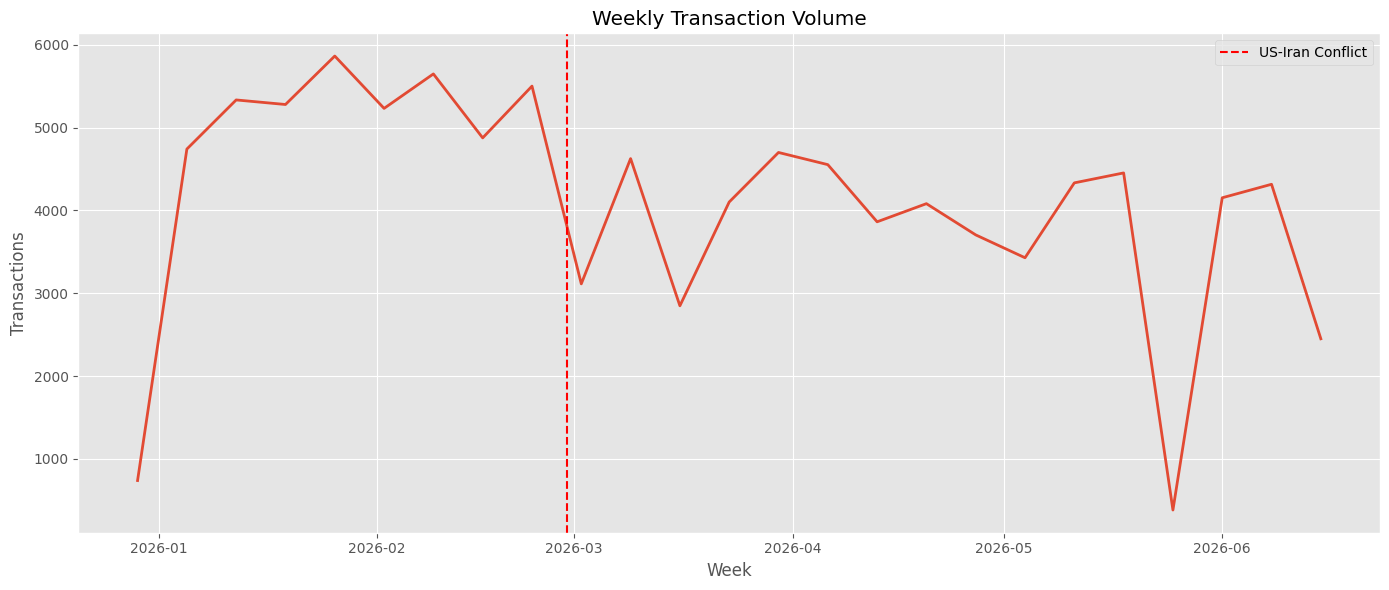

In [6]:
###############################################################
# Figure 1
# Weekly Transaction Volume
###############################################################

plt.figure(figsize=(14,6))

plt.plot(
    weekly_market["week"],
    weekly_market["transaction_count"],
    linewidth=2
)

plt.axvline(
    pd.Timestamp("2026-02-28"),
    color="red",
    linestyle="--",
    label="US-Iran Conflict"
)

plt.title("Weekly Transaction Volume")

plt.xlabel("Week")

plt.ylabel("Transactions")

plt.legend()

plt.tight_layout()

plt.show()

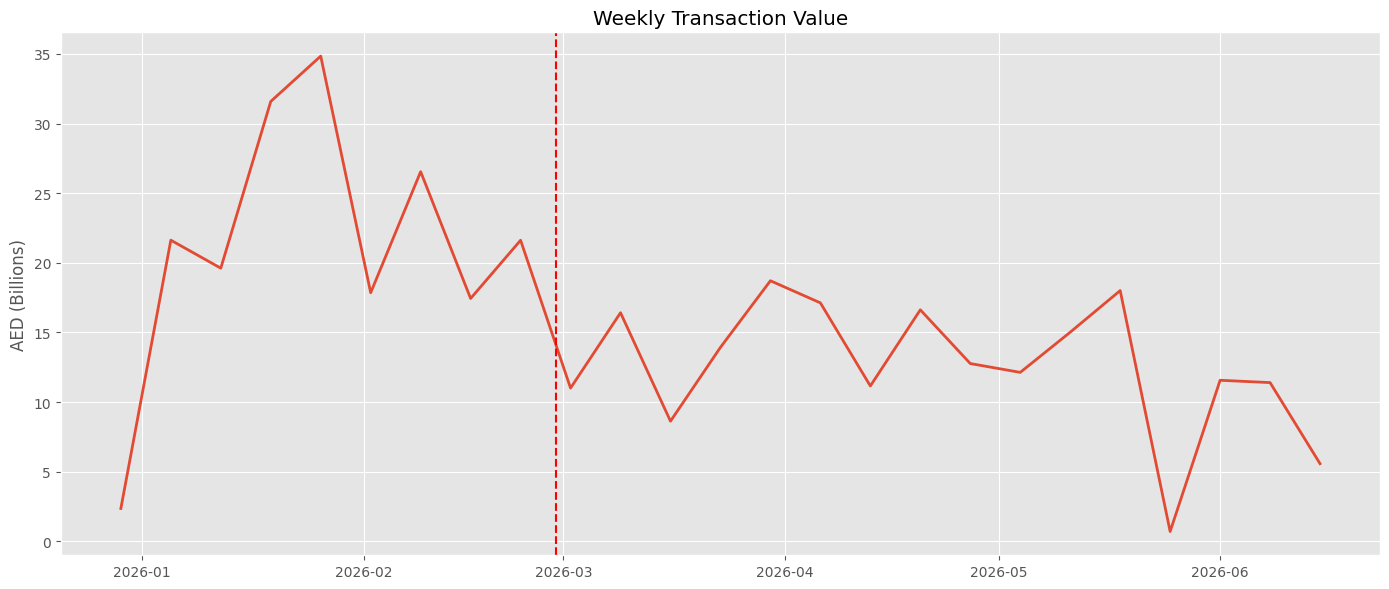

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_market["week"],
    weekly_market["total_transaction_value"]/1e9,
    linewidth=2
)

plt.axvline(
    pd.Timestamp("2026-02-28"),
    color="red",
    linestyle="--",
    label="US-Iran Conflict"
)

plt.title("Weekly Transaction Value")

plt.ylabel("AED (Billions)")

plt.tight_layout()


plt.show()

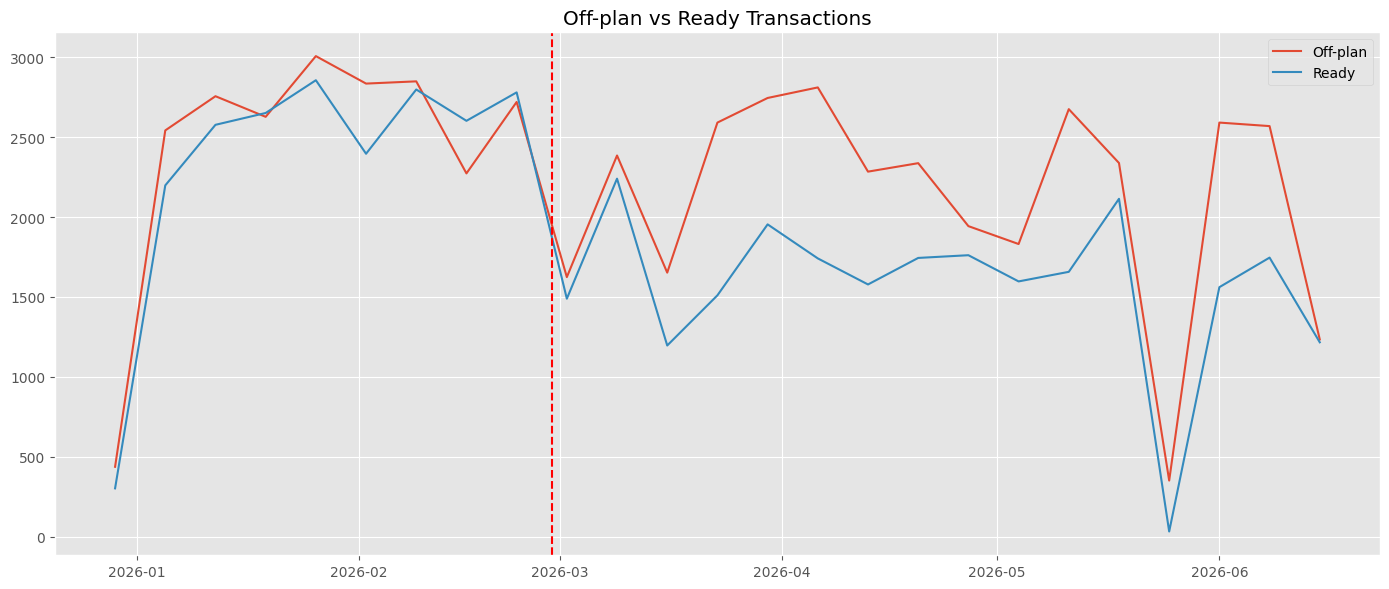

In [8]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_market["week"],
    weekly_market["offplan_transactions"],
    label="Off-plan"
)

plt.plot(
    weekly_market["week"],
    weekly_market["ready_transactions"],
    label="Ready"
)

plt.axvline(
    pd.Timestamp("2026-02-28"),
    color="red",
    linestyle="--"
)

plt.legend()

plt.title("Off-plan vs Ready Transactions")

plt.tight_layout()


plt.show()

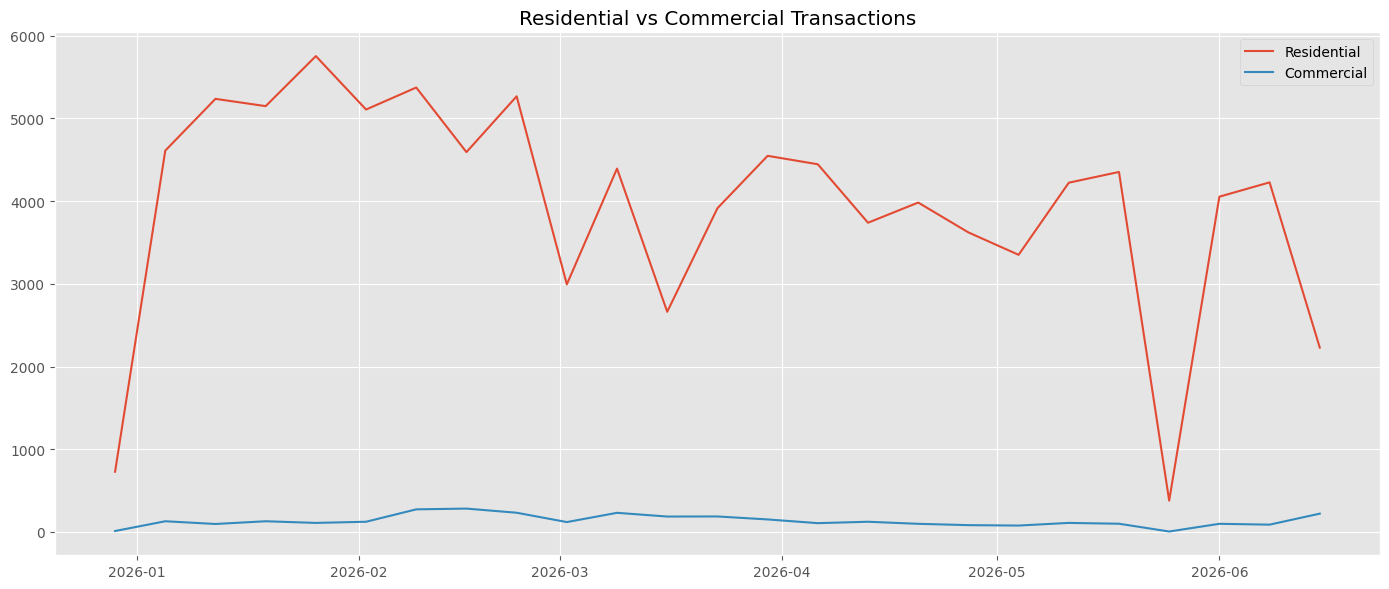

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_market["week"],
    weekly_market["residential_transactions"],
    label="Residential"
)

plt.plot(
    weekly_market["week"],
    weekly_market["commercial_transactions"],
    label="Commercial"
)

plt.legend()

plt.title("Residential vs Commercial Transactions")

plt.tight_layout()

plt.show()

In [10]:
print(df['USAGE_EN'].value_counts(dropna=False))

USAGE_EN
Residential    98939
Commercial      3364
Name: count, dtype: int64


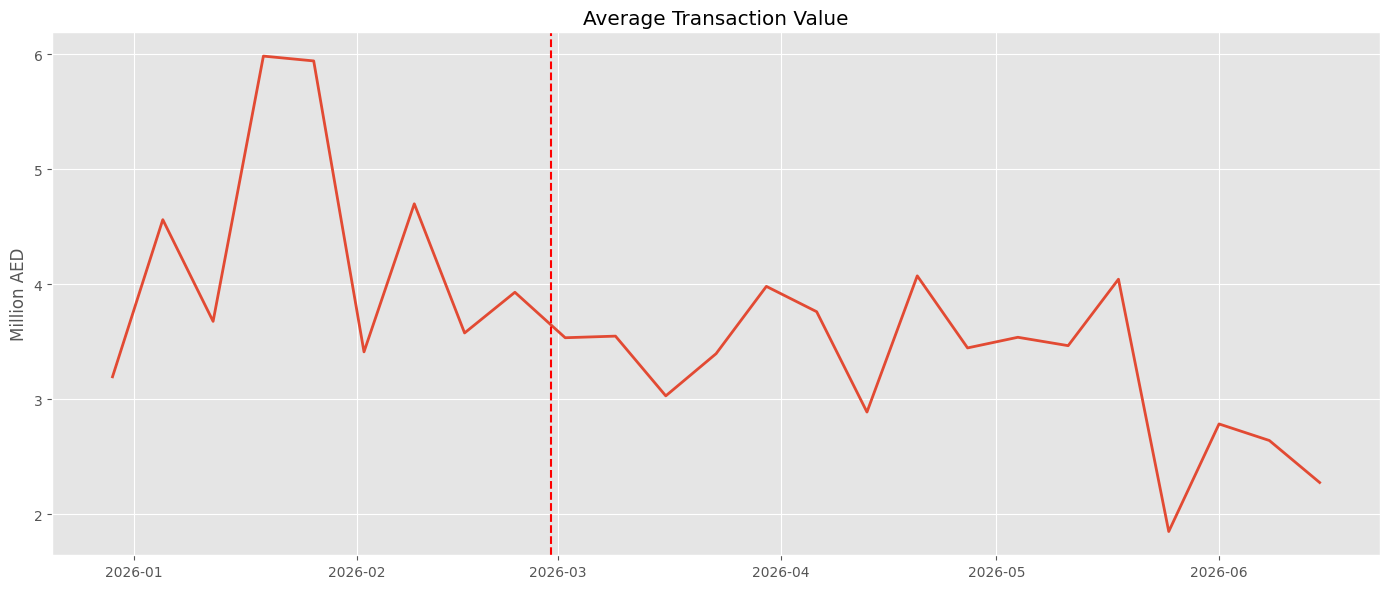

In [11]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_market["week"],
    weekly_market["average_transaction_value"]/1e6,
    linewidth=2
)

plt.axvline(
    pd.Timestamp("2026-02-28"),
    color="red",
    linestyle="--"
)

plt.ylabel("Million AED")

plt.title("Average Transaction Value")

plt.tight_layout()

plt.show()

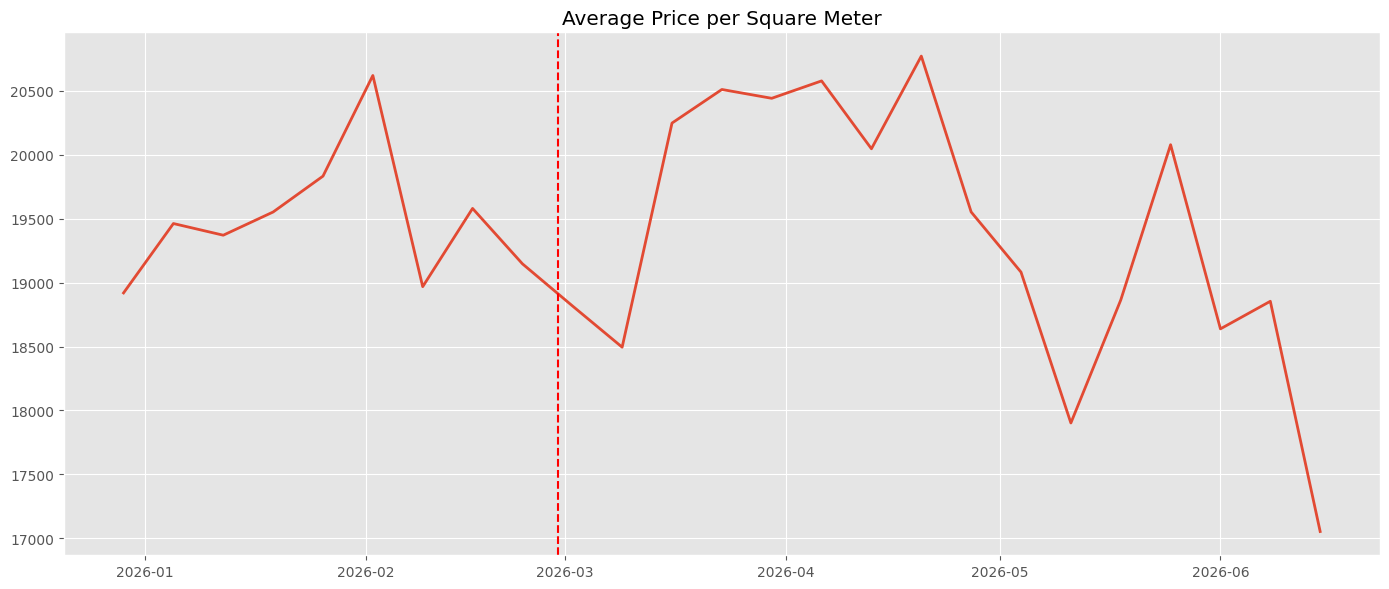

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_market["week"],
    weekly_market["average_price_per_sqm"],
    linewidth=2
)

plt.axvline(
    pd.Timestamp("2026-02-28"),
    color="red",
    linestyle="--"
)

plt.title("Average Price per Square Meter")

plt.tight_layout()

plt.show()

In [13]:
transaction_value_type = df.groupby('week').agg(
    sales_transaction_value=(
        'TRANS_VALUE',
        lambda x: x[df.loc[x.index, 'is_sale']].sum()
    ),
    mortgage_transaction_value=(
        'TRANS_VALUE',
        lambda x: x[df.loc[x.index, 'is_mortgage']].sum()
    ),
    gift_transaction_value=(
        'TRANS_VALUE',
        lambda x: x[df.loc[x.index, 'is_gift']].sum()
    )
).reset_index()

In [14]:
display(transaction_value_type)

,week,sales_transaction_value,mortgage_transaction_value,gift_transaction_value
0,2025-12-29,1.756563e+09,5.399898e+08,6.523353e+07
1,2026-01-05,1.337354e+10,6.831573e+09,1.419909e+09
2,2026-01-12,1.502532e+10,3.481105e+09,1.108558e+09
3,2026-01-19,2.402136e+10,5.580948e+09,1.983505e+09
4,2026-01-26,1.815458e+10,1.518646e+10,1.499834e+09
5,2026-02-02,1.414941e+10,2.847485e+09,8.550791e+08
6,2026-02-09,1.872567e+10,4.342239e+09,3.474999e+09
7,2026-02-16,1.378642e+10,2.945090e+09,7.073548e+08
8,2026-02-23,1.391138e+10,5.854438e+09,1.854199e+09
9,2026-03-02,8.250435e+09,2.295029e+09,4.608075e+08


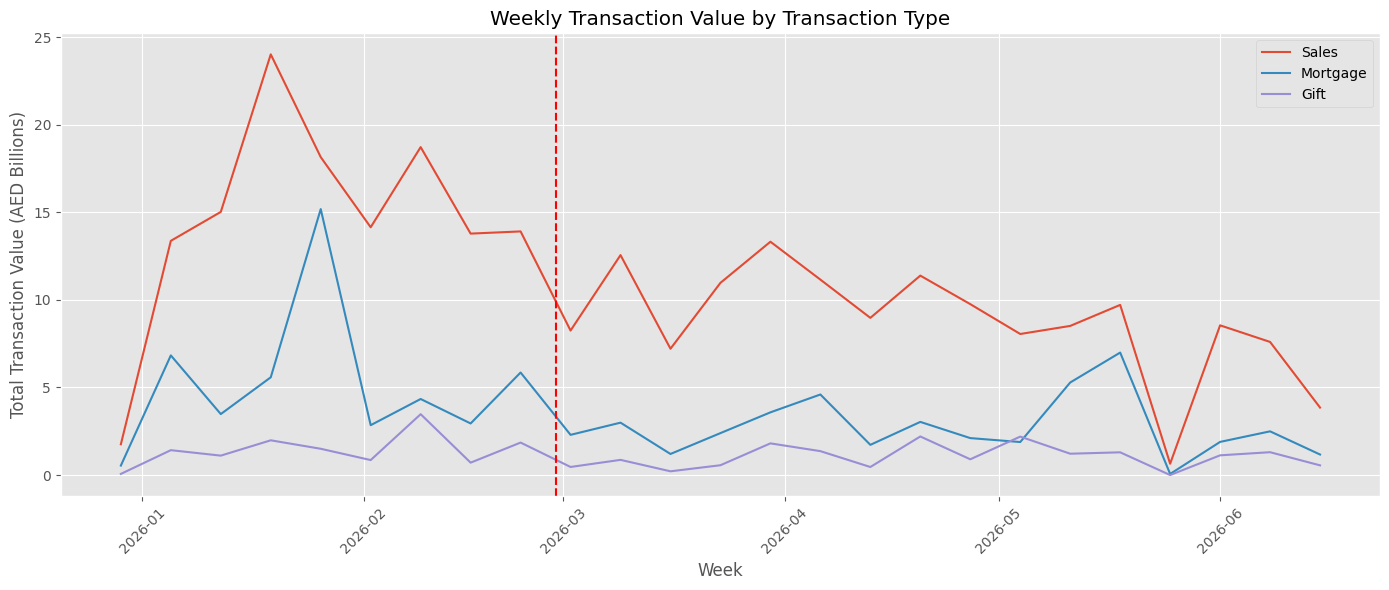

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    transaction_value_type['week'],
    transaction_value_type['sales_transaction_value'] / 1e9,
    label='Sales'
)

plt.plot(
    transaction_value_type['week'],
    transaction_value_type['mortgage_transaction_value'] / 1e9,
    label='Mortgage'
)

plt.plot(
    transaction_value_type['week'],
    transaction_value_type['gift_transaction_value'] / 1e9,
    label='Gift'
)

plt.axvline(
    pd.Timestamp("2026-02-28"),
    color="red",
    linestyle="--"
)

plt.xlabel('Week')
plt.ylabel('Total Transaction Value (AED Billions)')
plt.title('Weekly Transaction Value by Transaction Type')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
community = (
    df.groupby(["week", "AREA_EN"])
      .agg(
          transaction_count=("TRANS_VALUE", "size"),
          sales_value=("TRANS_VALUE", "sum"),
          average_price=("TRANS_VALUE", "mean"),
          average_price_per_sqm=("price_per_sqm", "mean")
      )
      .reset_index()
)

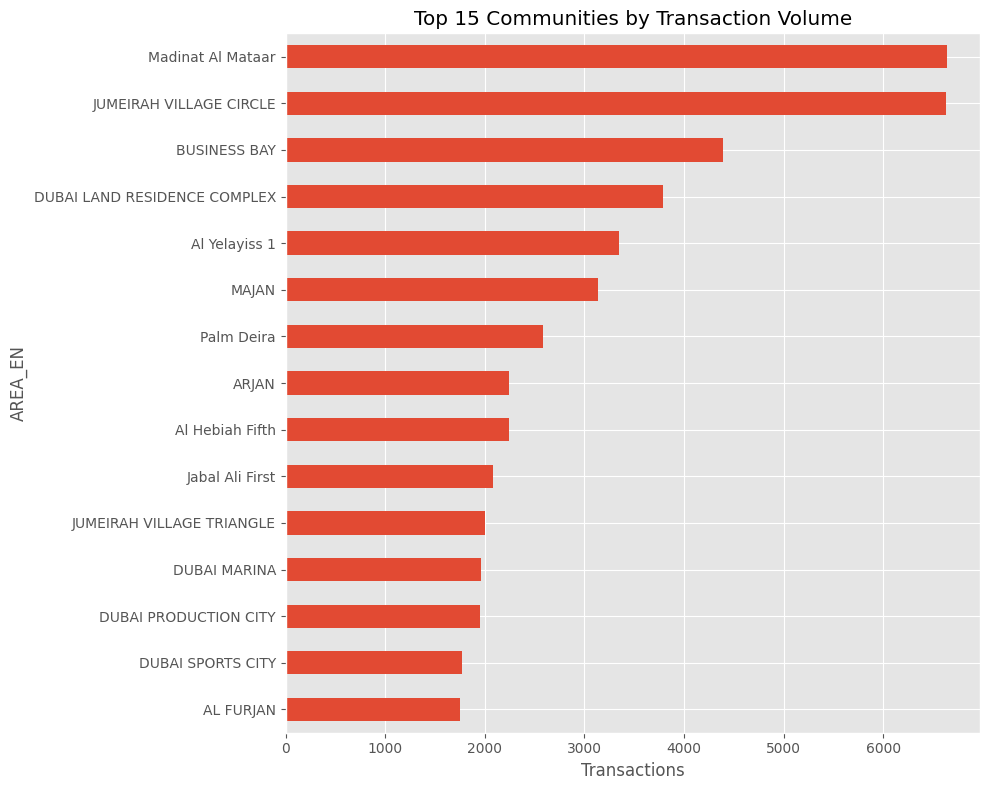

In [19]:
community_rank = (

    community
    .groupby("AREA_EN")["transaction_count"]
    .sum()
    .sort_values(ascending=False)
    .head(15)

)

plt.figure(figsize=(10,8))

community_rank.sort_values().plot.barh()

plt.xlabel("Transactions")

plt.title("Top 15 Communities by Transaction Volume")

plt.tight_layout()

plt.show()

# **DLD and Social Media (SMDI)**

In [20]:
# ============================================================
# IMPORT SMDI POSTS
# ============================================================

import pandas as pd

smdi_path = "/content/drive/MyDrive/Dubai_Real_Estate_Data/SMDI creation"

smdi_posts = pd.read_csv(
    f"{smdi_path}/smdi_posts.csv"
)

print("SMDI posts imported successfully!")
print(f"Number of posts: {len(smdi_posts):,}")
print(f"Number of columns: {len(smdi_posts.columns)}")

display(smdi_posts.head())

SMDI posts imported successfully!
Number of posts: 87,574
Number of columns: 40


,id,raw_text,clean_text,date,platform,source_label,post_type,platform_interaction_value,platform_interaction_definition,likeCount,...,agent_listing_cues_matched,is_likely_agent_listing,is_domain_relevant,pipeline_keep_final,yearweek,month,week_num,topic,semantic_group,SMDI
0,2027768456926630139,"BREAKING:\n\nDubai, right now. https://t.co/QF...","BREAKING: Dubai, right now.",2026-02-28 00:00:00+00:00,twitter,both,tweet,137404.0,Twitter/X source-native total interactions: li...,104472.0,...,NaN,0.0,1.0,1.0,2026-W09,2026-02,9.0,455,16,NaN
1,2030885084685910418,They spent years showing off their Dubai lifes...,They spent years showing off their Dubai lifes...,2026-03-09 00:00:00+00:00,twitter,both,tweet,82403.0,Twitter/X source-native total interactions: li...,55739.0,...,NaN,0.0,1.0,1.0,2026-W11,2026-03,11.0,-1,16,NaN
2,2027846642393653581,Dubai is done.\n\nIt will be nearly impossible...,Dubai is done. It will be nearly impossible fo...,2026-02-28 00:00:00+00:00,twitter,both,tweet,102497.0,Twitter/X source-native total interactions: li...,90090.0,...,NaN,0.0,1.0,1.0,2026-W09,2026-02,9.0,-1,16,NaN
3,2036211395902001411,i can’t believe people prefer going to Dubai t...,i can’t believe people prefer going to Dubai t...,2026-03-23 00:00:00+00:00,twitter,semantic,tweet,86850.0,Twitter/X source-native total interactions: li...,78914.0,...,NaN,0.0,1.0,1.0,2026-W13,2026-03,13.0,-1,16,NaN
4,2027727164364493003,Dubai just shut down. The busiest internationa...,Dubai just shut down. The busiest internationa...,2026-02-28 00:00:00+00:00,twitter,both,tweet,58851.0,Twitter/X source-native total interactions: li...,43016.0,...,NaN,0.0,1.0,1.0,2026-W09,2026-02,9.0,-1,16,NaN


In [24]:
# ============================================================
# 6. CALCULATE WEEKLY POST FREQUENCY
# ============================================================

smdi_posts['date'] = pd.to_datetime(
    smdi_posts['date'],
    errors='coerce'
)

smdi_posts = smdi_posts.dropna(subset=['date'])

smdi_posts['week'] = (
    smdi_posts['date']
    .dt.to_period('W')
    .apply(lambda r: r.start_time)
)


# Keep only posts that have one of the five SMDI labels
labelled_smdi_posts = smdi_posts[
    smdi_posts['SMDI'].notna()
].copy()

weekly_smdi = (
    labelled_smdi_posts
    .groupby(['week', 'SMDI'])
    .size()
    .reset_index(name='post_frequency')
)

display(weekly_smdi.head(20))

,week,SMDI,post_frequency
0,2025-12-29,Developer Activity,9
1,2025-12-29,Geopolitical,1
2,2025-12-29,Location,3
3,2025-12-29,Market Price,33
4,2025-12-29,Rental Legal,31
5,2026-01-05,Developer Activity,40
6,2026-01-05,Geopolitical,3
7,2026-01-05,Location,10
8,2026-01-05,Market Price,95
9,2026-01-05,Rental Legal,98


In [25]:
# ============================================================
# WIDE FORMAT FOR ANALYSIS
# ============================================================

weekly_smdi_wide = (
    weekly_smdi
    .pivot(
        index='week',
        columns='SMDI',
        values='post_frequency'
    )
    .fillna(0)
    .reset_index()
)

# Rename/order the five SMDI columns
smdi_columns = [
    'Geopolitical',
    'Market Price',
    'Developer Activity',
    'Rental Legal',
    'Location'
]

weekly_smdi_wide = weekly_smdi_wide[
    ['week'] + smdi_columns
]

display(weekly_smdi_wide.head(20))

SMDI,week,Geopolitical,Market Price,Developer Activity,Rental Legal,Location
0,2025-12-29,1,33,9,31,3
1,2026-01-05,3,95,40,98,10
2,2026-01-12,7,99,34,95,10
3,2026-01-19,6,140,42,90,13
4,2026-01-26,5,88,37,115,15
5,2026-02-02,8,69,47,118,7
6,2026-02-09,13,101,46,131,15
7,2026-02-16,7,152,45,97,15
8,2026-02-23,63,144,23,144,15
9,2026-03-02,148,252,24,286,27


In [27]:
#dld: weekly_market
#smdi: weekly_smdi_wide

analysis_df = pd.merge(
    weekly_smdi_wide,
    weekly_market,
    on='week',
    how='inner'
)

analysis_df = analysis_df.sort_values('week').reset_index(drop=True)

print("SMDI rows:", len(weekly_smdi_wide))
print("DLD rows:", len(weekly_market))
print("Merged rows:", len(analysis_df))

display(analysis_df.head())

SMDI rows: 18
DLD rows: 25
Merged rows: 18


,week,Geopolitical,Market Price,Developer Activity,Rental Legal,Location,transaction_count,sales_count,mortgage_count,gift_count,...,offplan_share,ready_share,residential_share,commercial_share,minimum_price,maximum_price,std_price,transaction_growth,sales_growth,price_growth
0,2025-12-29,1,33,9,31,3,739,603,119,17,...,0.591340,0.408660,0.985115,0.014885,21053.95,1.215598e+08,7.013222e+06,NaN,NaN,NaN
1,2026-01-05,3,95,40,98,10,4740,3832,769,139,...,0.536287,0.463713,0.972785,0.027215,7947.81,4.250000e+09,6.256203e+07,5.414073,8.156214,0.427520
2,2026-01-12,7,99,34,95,10,5333,4208,931,194,...,0.516782,0.483218,0.981999,0.018001,2312.38,3.125000e+08,9.532187e+06,0.125105,-0.092950,-0.193809
3,2026-01-19,6,140,42,90,13,5278,4154,875,249,...,0.497726,0.502274,0.975559,0.024441,15157.54,3.130255e+09,6.195039e+07,-0.010313,0.610290,0.627070
4,2026-01-26,5,88,37,115,15,5863,4627,985,251,...,0.512877,0.487123,0.981409,0.018591,62212.84,1.034807e+10,1.361294e+08,0.110837,0.103054,-0.007006


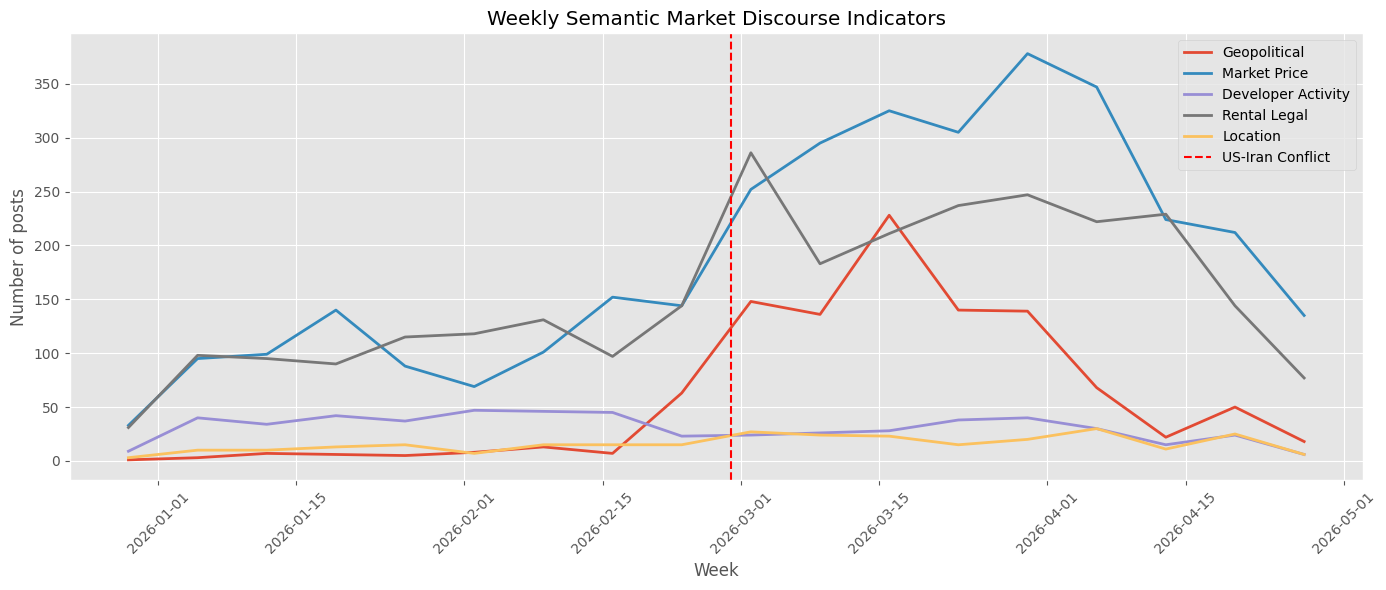

In [30]:
# ============================================================
# GRAPH 1: WEEKLY SMDI FREQUENCY
# ============================================================

plt.figure(figsize=(14, 6))

smdi_columns = [
    'Geopolitical',
    'Market Price',
    'Developer Activity',
    'Rental Legal',
    'Location'
]

for col in smdi_columns:
    plt.plot(
        analysis_df['week'],
        analysis_df[col],
        label=col,
        linewidth=2
    )


plt.axvline(
    pd.Timestamp("2026-02-28"),
    color="red",
    linestyle="--",
    label="US-Iran Conflict"
)

plt.xlabel("Week")
plt.ylabel("Number of posts")
plt.title("Weekly Semantic Market Discourse Indicators")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

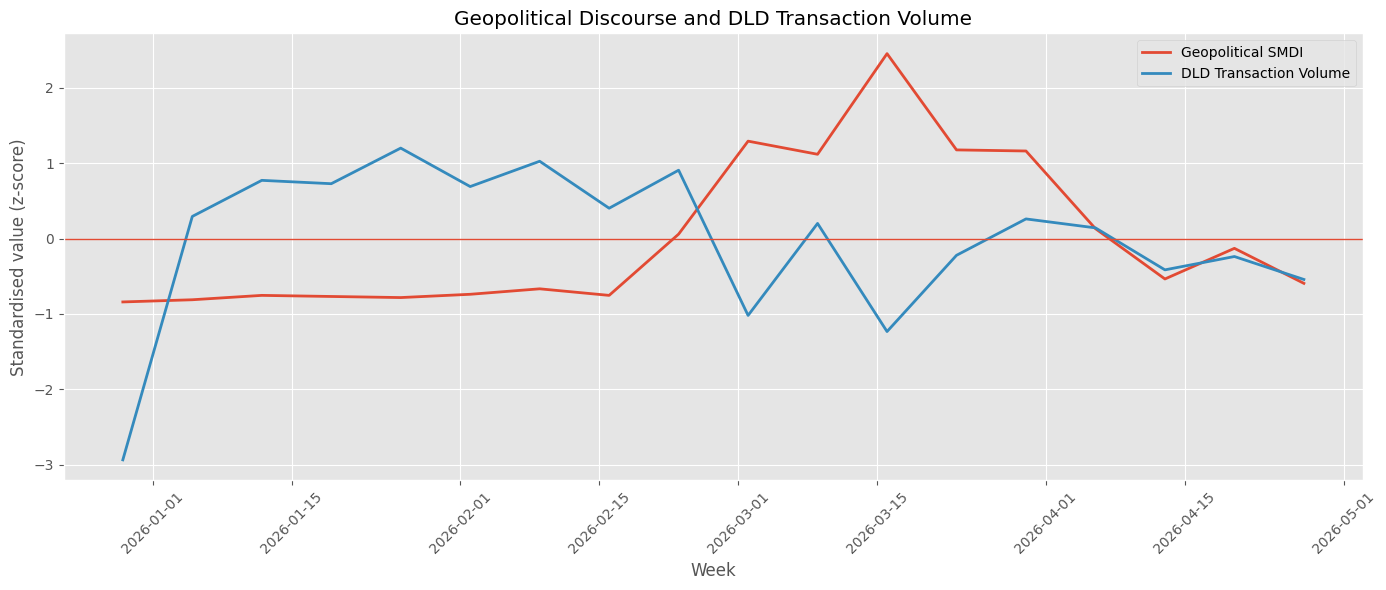

In [31]:
# ============================================================
# GRAPH 2: GEOPOLITICAL VS TRANSACTION VOLUME
# ============================================================

plot_df = analysis_df.copy()

plot_df['Geopolitical_z'] = (
    plot_df['Geopolitical'] -
    plot_df['Geopolitical'].mean()
) / plot_df['Geopolitical'].std()

plot_df['transaction_count_z'] = (
    plot_df['transaction_count'] -
    plot_df['transaction_count'].mean()
) / plot_df['transaction_count'].std()

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df['week'],
    plot_df['Geopolitical_z'],
    label='Geopolitical SMDI',
    linewidth=2
)

plt.plot(
    plot_df['week'],
    plot_df['transaction_count_z'],
    label='DLD Transaction Volume',
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.xlabel("Week")
plt.ylabel("Standardised value (z-score)")
plt.title(
    "Geopolitical Discourse and DLD Transaction Volume"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

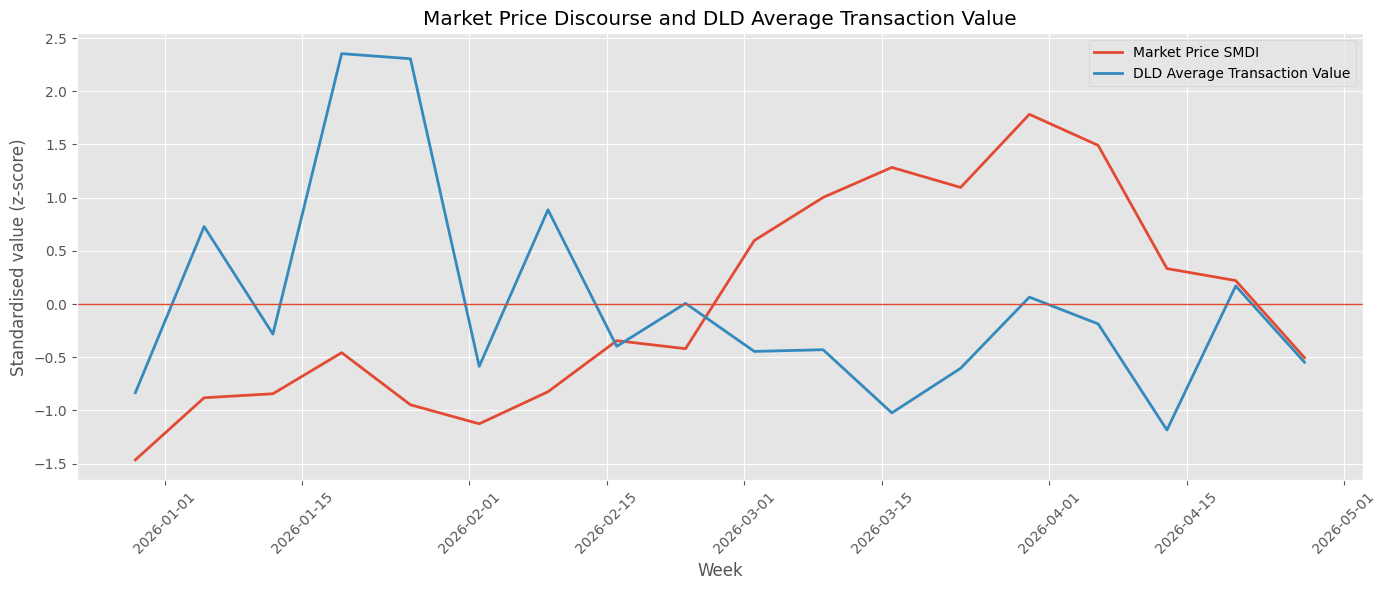

In [32]:
# ============================================================
# GRAPH 3: MARKET PRICE SMDI VS DLD TRANSACTION VALUE
# ============================================================

plot_df = analysis_df.copy()

plot_df['MarketPrice_z'] = (
    plot_df['Market Price'] -
    plot_df['Market Price'].mean()
) / plot_df['Market Price'].std()

plot_df['average_value_z'] = (
    plot_df['average_transaction_value'] -
    plot_df['average_transaction_value'].mean()
) / plot_df['average_transaction_value'].std()

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df['week'],
    plot_df['MarketPrice_z'],
    label='Market Price SMDI',
    linewidth=2
)

plt.plot(
    plot_df['week'],
    plot_df['average_value_z'],
    label='DLD Average Transaction Value',
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.xlabel("Week")
plt.ylabel("Standardised value (z-score)")
plt.title(
    "Market Price Discourse and DLD Average Transaction Value"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

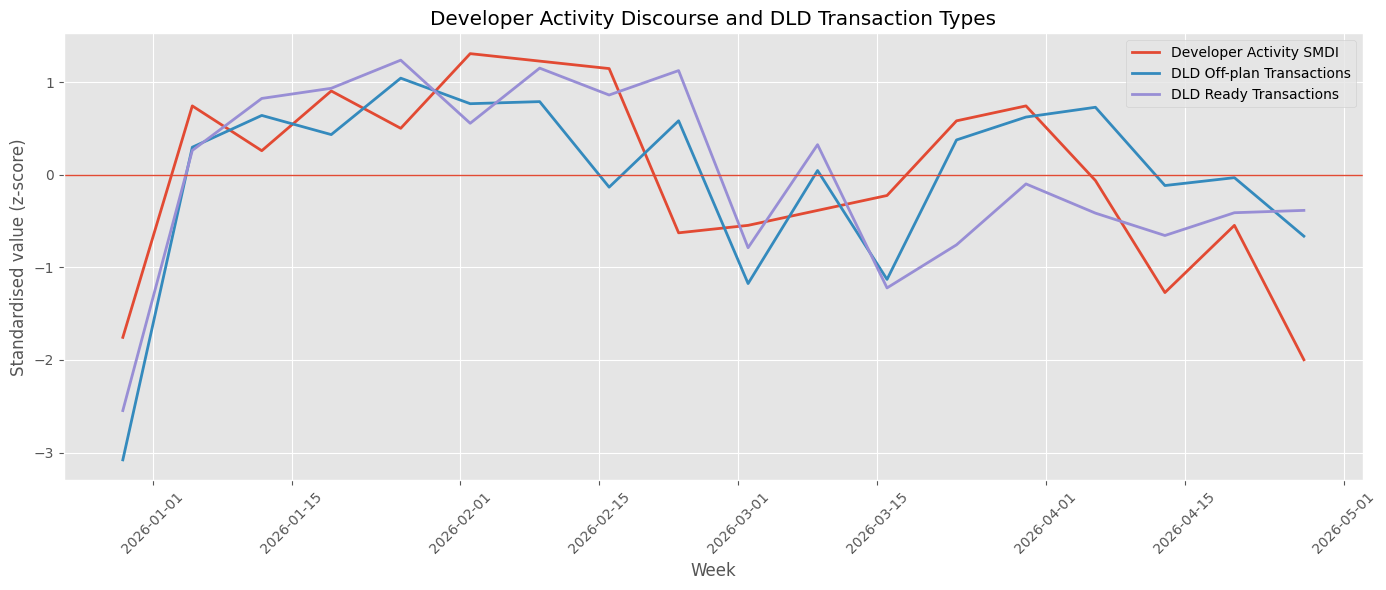

In [33]:
# ============================================================
# GRAPH 4: DEVELOPER ACTIVITY VS OFF-PLAN / READY
# ============================================================

plot_df = analysis_df.copy()

# Standardise all three series
for col in [
    'Developer Activity',
    'offplan_transactions',
    'ready_transactions'
]:
    plot_df[col + '_z'] = (
        plot_df[col] - plot_df[col].mean()
    ) / plot_df[col].std()

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df['week'],
    plot_df['Developer Activity_z'],
    label='Developer Activity SMDI',
    linewidth=2
)

plt.plot(
    plot_df['week'],
    plot_df['offplan_transactions_z'],
    label='DLD Off-plan Transactions',
    linewidth=2
)

plt.plot(
    plot_df['week'],
    plot_df['ready_transactions_z'],
    label='DLD Ready Transactions',
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.xlabel("Week")
plt.ylabel("Standardised value (z-score)")
plt.title(
    "Developer Activity Discourse and DLD Transaction Types"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

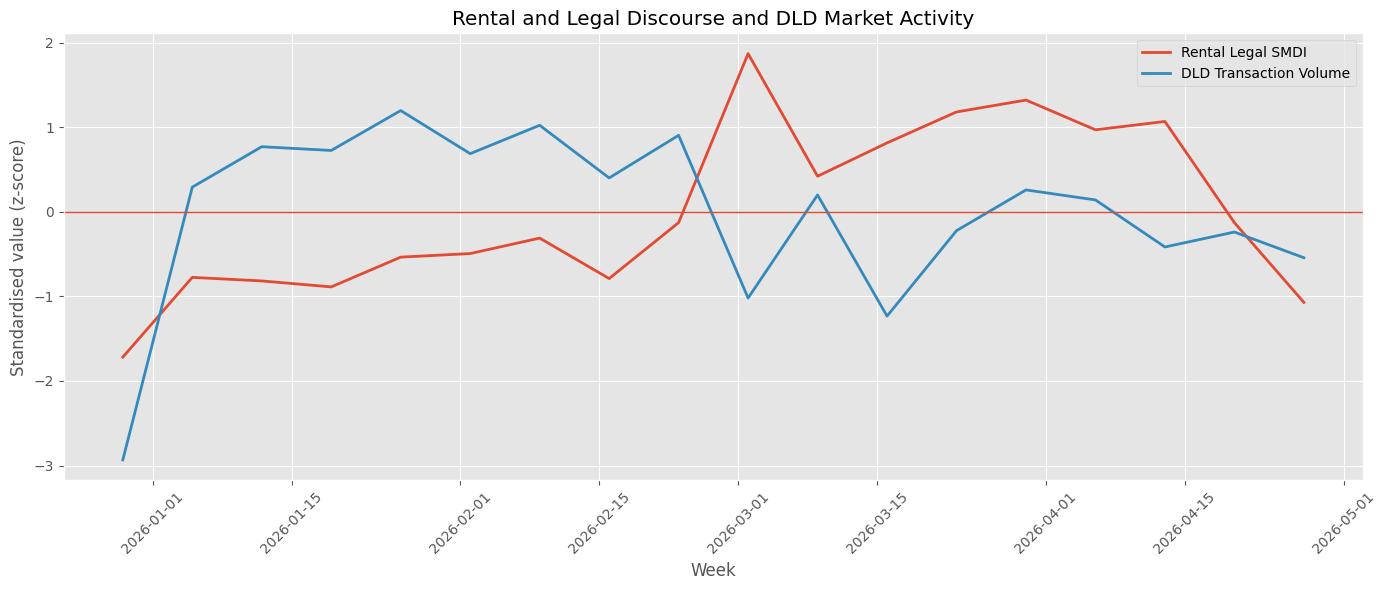

In [34]:
# ============================================================
# GRAPH 5: RENTAL LEGAL VS MARKET ACTIVITY
# ============================================================

plot_df = analysis_df.copy()

plot_df['RentalLegal_z'] = (
    plot_df['Rental Legal'] -
    plot_df['Rental Legal'].mean()
) / plot_df['Rental Legal'].std()

plot_df['transaction_count_z'] = (
    plot_df['transaction_count'] -
    plot_df['transaction_count'].mean()
) / plot_df['transaction_count'].std()

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df['week'],
    plot_df['RentalLegal_z'],
    label='Rental Legal SMDI',
    linewidth=2
)

plt.plot(
    plot_df['week'],
    plot_df['transaction_count_z'],
    label='DLD Transaction Volume',
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.xlabel("Week")
plt.ylabel("Standardised value (z-score)")
plt.title(
    "Rental and Legal Discourse and DLD Market Activity"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

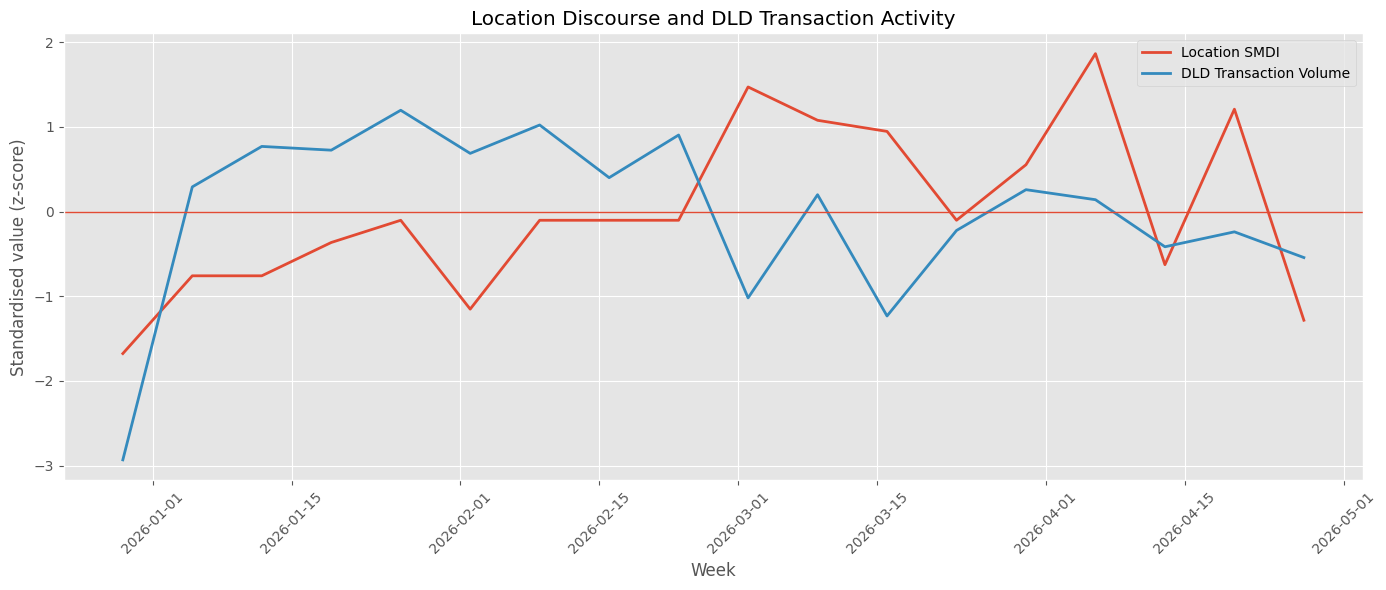

In [35]:
# ============================================================
# GRAPH 6: LOCATION SMDI VS MARKET ACTIVITY
# ============================================================

plot_df = analysis_df.copy()

plot_df['Location_z'] = (
    plot_df['Location'] -
    plot_df['Location'].mean()
) / plot_df['Location'].std()

plot_df['transaction_count_z'] = (
    plot_df['transaction_count'] -
    plot_df['transaction_count'].mean()
) / plot_df['transaction_count'].std()

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df['week'],
    plot_df['Location_z'],
    label='Location SMDI',
    linewidth=2
)

plt.plot(
    plot_df['week'],
    plot_df['transaction_count_z'],
    label='DLD Transaction Volume',
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.xlabel("Week")
plt.ylabel("Standardised value (z-score)")
plt.title(
    "Location Discourse and DLD Transaction Activity"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

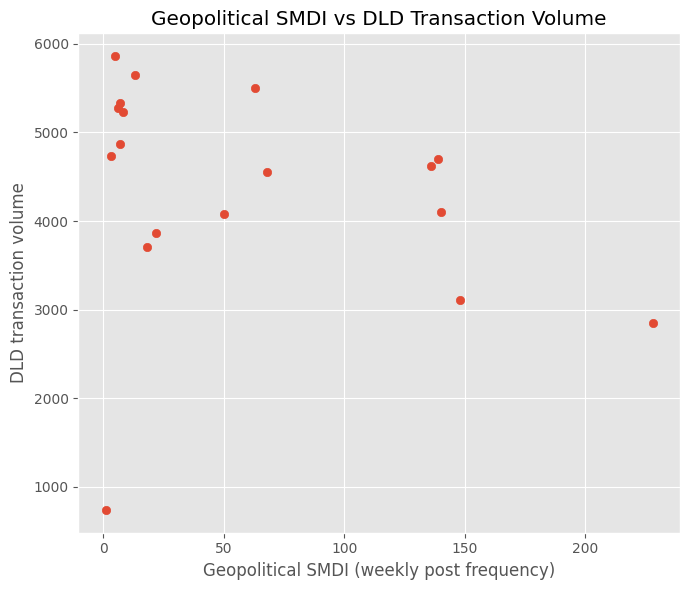

In [37]:
# ============================================================
# SCATTER: GEOPOLITICAL VS TRANSACTION VOLUME
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    analysis_df['Geopolitical'],
    analysis_df['transaction_count']
)

plt.xlabel("Geopolitical SMDI (weekly post frequency)")
plt.ylabel("DLD transaction volume")
plt.title(
    "Geopolitical SMDI vs DLD Transaction Volume"
)

plt.tight_layout()
plt.show()